In [1]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [3]:
#filter trait data to minimize colinearity
filter = 0.70
f_trait_data = quality_filter(trait_data, filter)

print(f'\n{f_trait_data.shape[0]} traits')


initializing: M12_poststress_GLU

M12_poststress_BW corr: 0.023720658191998683
M12_poststress_FM_g corr: 0.15170584503159446
M12_poststress_food_g corr: 0.1572267599168086
M12_poststress_FFM_g corr: 0.016038987694264484
M10_poststress_FFM_g corr: 0.1032664053853798
M10_poststress_food_g corr: 0.15795322028701717
M10_poststress_BW corr: 0.15622879032638945
M10_poststress_GLU corr: 0.6719015152375838
M10_poststress_FM_g corr: 0.3359654636524691
M8_poststress_FFM_g corr: 0.13022424239458588
M8_poststress_FM_g corr: 0.30474076619102525
M8_poststress_GLU corr: 0.6090336912254721
M8_poststress_BW corr: 0.2725029351380857
M8_poststress_food_g corr: 0.11015798652162395
M6_poststress_FFM_g corr: 0.14497224377218185
M6_poststress_GLU corr: 0.5802400592602832
M6_poststress_FM_g corr: 0.5008174335569449
M6_poststress_BW corr: 0.20714440200743167
M6_poststress_food_g corr: 0.24895087822309858
M4_poststress_FFM_g corr: 0.13864898633105477
M4_poststress_BW corr: 0.2844628216470895
M4_poststress_food

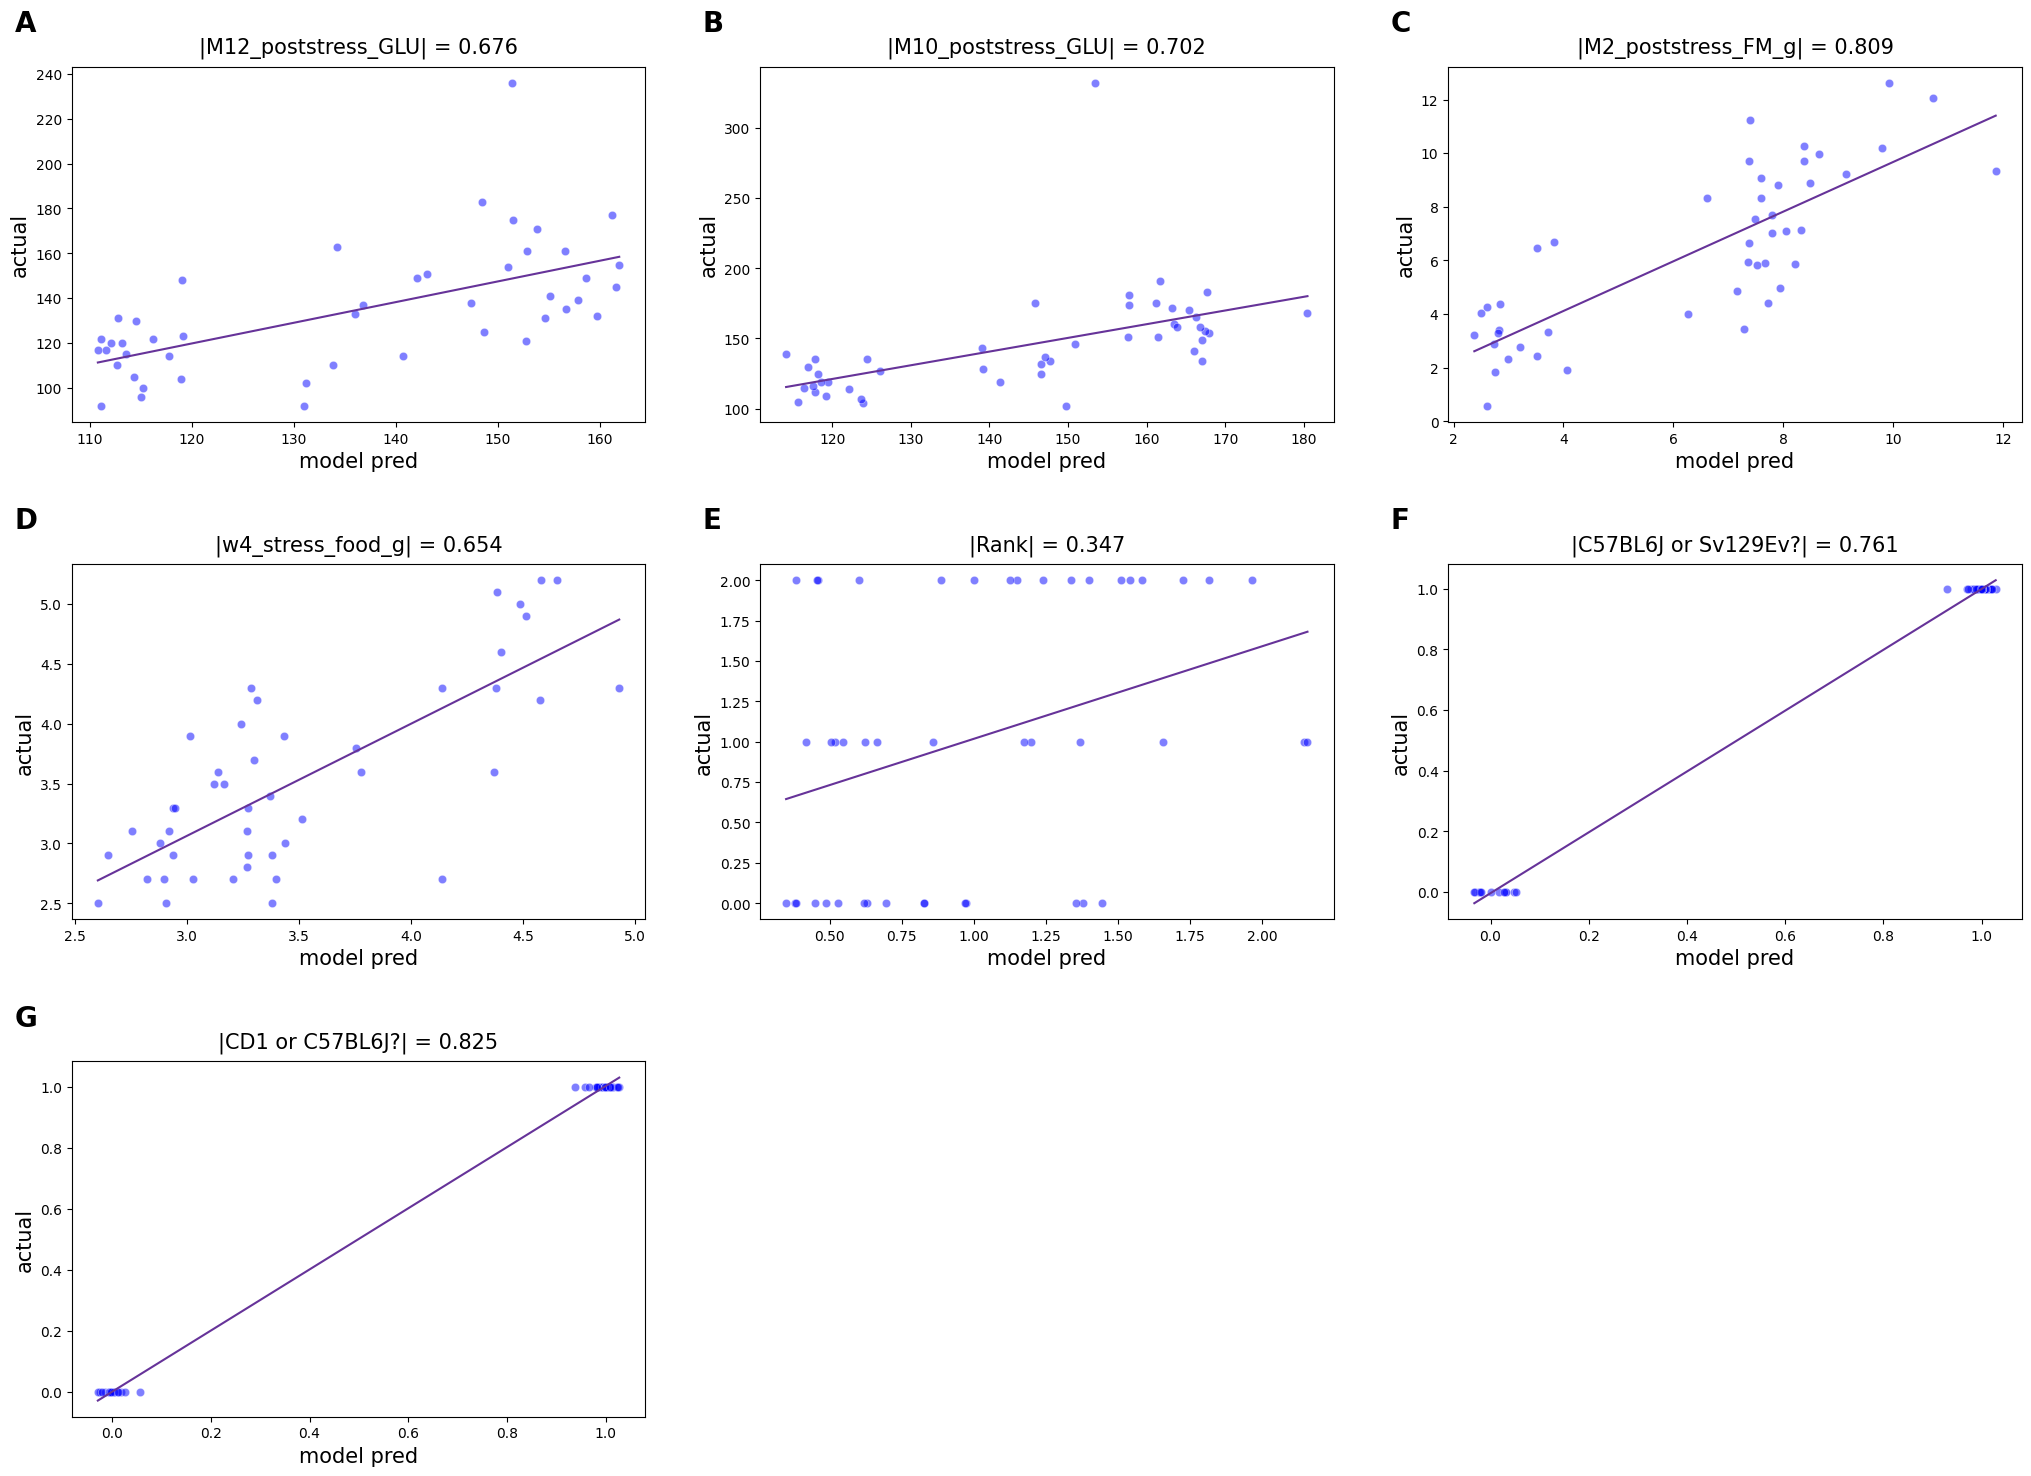

In [4]:
#generate pseudoinversion plots
thresh = 0.60
meth_filter_thresh = 0.50
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

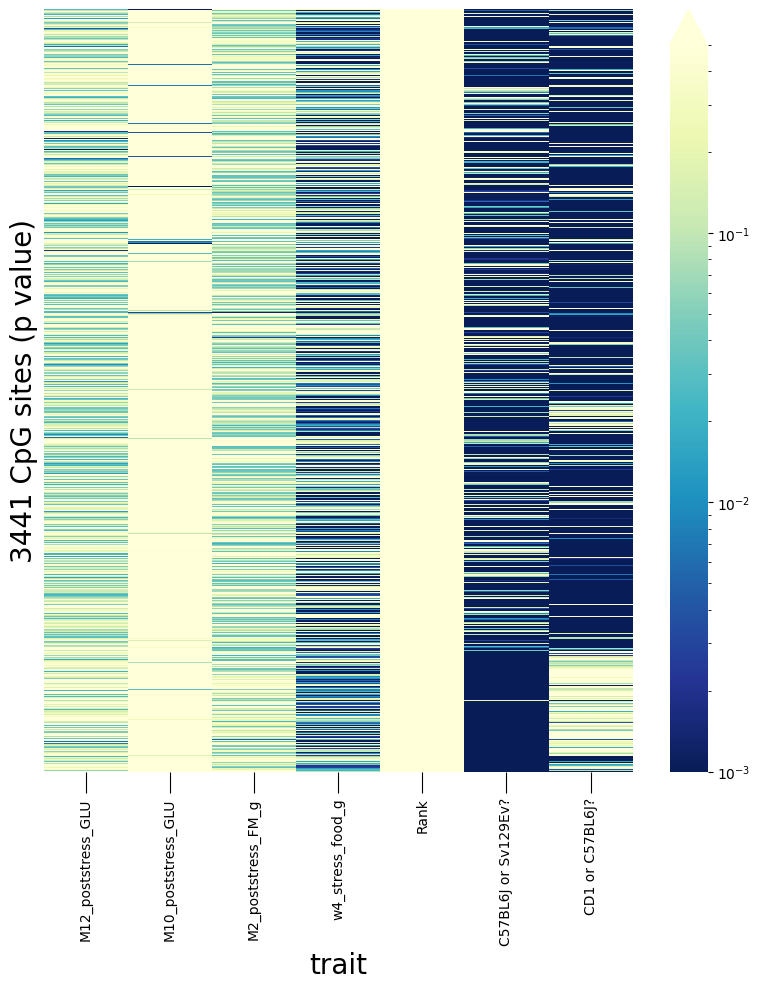

In [5]:
#generate heatmap of probe/trait multivar association p values
is_filtered = True
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [6]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

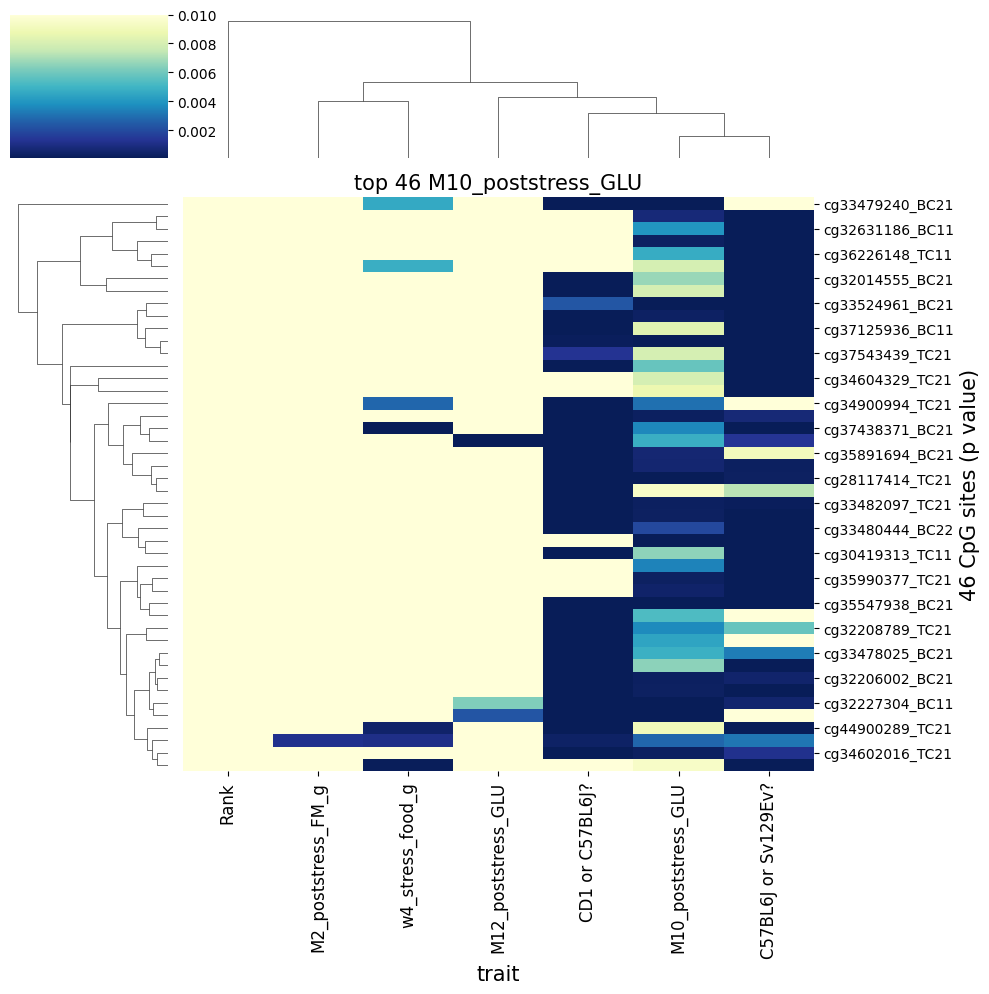

In [7]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [8]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

#trait_vals.to_excel('pseudoinverse_probes_filtered.xlsx')

trait_vals

,M12_poststress_GLU_pval,M12_poststress_GLU_coef,M10_poststress_GLU_pval,M10_poststress_GLU_coef,M2_poststress_FM_g_pval,M2_poststress_FM_g_coef,w4_stress_food_g_pval,w4_stress_food_g_coef,Rank_pval,Rank_coef,...,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg28113426_BC11,0.789472,-0.000047,0.999869,-0.000100,0.666153,0.000982,0.103131,0.009125,0.932579,-0.006018,...,0.000548,2.484416e-34,0.658940,chr10,3802852,3802854,chr10,3852852.0,3852854.0,"Mthfd1l (-120,278), Plekhg1 (+112,489)"
cg28116521_BC11,0.047950,0.001197,0.000617,-0.002046,0.656930,0.003467,0.253699,0.021870,0.949554,0.010958,...,0.153297,5.054036e-14,0.553085,chr10,4080228,4080230,chr10,4130228.0,4130230.0,"Akap12 (-136,151), Mthfd1l (+157,098)"
cg28117414_TC21,0.026428,0.001809,0.000098,-0.002977,0.718192,0.003518,0.338840,0.022692,0.932579,0.026716,...,0.185056,1.275127e-15,0.772848,chr10,4163086,4163088,chr10,4213086.0,4213088.0,"Akap12 (-53,293), Mthfd1l (+239,956)"
cg28133420_BC21,0.208246,-0.000816,0.542007,-0.000954,0.158403,0.011688,0.106849,0.034970,0.976928,-0.004627,...,0.831722,6.841638e-02,0.104130,chr10,5993540,5993542,chr10,6043540.0,6043542.0,"Rgs17 (-121,141), Gm10945 (+718,220)"
cg28139216_TC21,0.009633,0.001194,0.408146,0.000585,0.981661,-0.000143,0.393499,0.010521,0.979496,-0.001615,...,-0.068422,3.241041e-05,0.142249,chr10,7002802,7002804,chr10,7052802.0,7052804.0,"Ipcef1 (-73,092), Cnksr3 (+159,434)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343126_BC21,0.061713,0.001008,0.999869,0.000397,0.995207,0.000056,0.023607,0.039632,0.958641,0.005088,...,0.459760,8.509403e-02,-0.079096,chrY,90730534,90730536,chrY,90719265.0,90719267.0,"Gm21996 (-973,734), Erdr1 (-65,472)"
cg48343211_TC11,0.314035,0.000595,0.466164,0.000913,0.285269,0.008080,0.035858,0.041461,0.985060,0.001283,...,0.493651,9.356343e-02,-0.087256,chrY,90737336,90737338,chrY,90726067.0,90726069.0,"Gm21996 (-980,536), Erdr1 (-58,670)"
cg48343225_BC11,0.784284,0.000154,0.999869,0.000133,0.493321,0.004791,0.006852,0.049115,0.949554,-0.008348,...,0.516767,9.808872e-01,0.001314,chrY,90738474,90738476,chrY,90727205.0,90727207.0,"Gm21996 (-981,674), Erdr1 (-57,532)"


In [9]:
#get unfiltered probe set

is_filtered = False
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=False, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [10]:
#find gene associations of probes via GREAT

probe_df = get_pos(trait_vals, mm39_data)

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

#trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')

trait_vals

,M10_poststress_GLU_pval,M10_poststress_GLU_coef,M2_poststress_food_g_pval,M2_poststress_food_g_coef,M2_poststress_GLU_pval,M2_poststress_GLU_coef,M2_poststress_FM_g_pval,M2_poststress_FM_g_coef,w4_stress_food_g_pval,w4_stress_food_g_coef,...,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg00101675_BC21,0.999992,0.000019,0.036602,0.057491,0.583755,0.000899,0.567397,0.006913,0.036522,0.050597,...,0.178581,0.977221,0.019053,chr12,75562492,75562494,chr12,75515718.0,75515720.0,"Gphb5 (-98,938), Ppp2r5e (+80,481)"
cg00116289_BC21,0.999992,0.000093,0.036602,0.055534,0.586997,0.000748,0.560335,0.010403,0.031400,0.058223,...,0.201787,0.955701,0.043484,chr15,12170935,12170937,chr15,12170849.0,12170851.0,"Mtmr12 (-34,178), Zfr (+53,019)"
cg00211372_TC21,0.999992,-0.000056,0.037895,0.051091,0.583755,0.000850,0.560335,0.010670,0.028672,0.065503,...,0.247751,0.949598,0.062549,chrX,56432743,56432745,chrX,57387383.0,57387385.0,"Arhgef6 (-48,655), Rbmx (+5,652)"
cg00531009_BC21,0.999992,0.000142,0.036602,0.051284,0.594219,0.000676,0.560335,0.009316,0.028672,0.060973,...,0.219745,0.954695,0.047958,chr19,6425966,6425968,chr19,6375936.0,6375938.0,"Pygm (-8,462), Sf1 (+12,247)"
cg00747726_TC21,0.999992,0.000438,0.077347,0.037551,0.583755,0.001457,0.693331,0.004255,0.082399,0.040378,...,0.154688,0.734972,0.093432,chr18,35705794,35705796,chr18,35572741.0,35572743.0,"Paip2 (-25,907), Matr3 (+10,584)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48344138_TC21,0.999992,0.000101,0.036602,0.044875,0.583755,0.001308,0.689840,0.003539,0.028672,0.048772,...,0.135710,0.953862,-0.040341,chrY,90819291,90819293,chrY,90808022.0,90808024.0,"Erdr1 (+23,285)"
cg48344145_TC21,0.999992,0.000252,0.712899,0.007938,0.732685,0.000380,0.939669,-0.000801,0.776783,0.006139,...,0.179066,0.223094,0.153517,chrY,90820137,90820139,chrY,90808868.0,90808870.0,"Erdr1 (+24,131)"
cg48344158_BC11,0.999992,0.000048,0.036602,0.060621,0.583755,0.001076,0.560335,0.009904,0.028672,0.067567,...,0.215005,0.980183,0.017906,chrY,90820804,90820806,chrY,90809535.0,90809537.0,"Erdr1 (+24,798)"


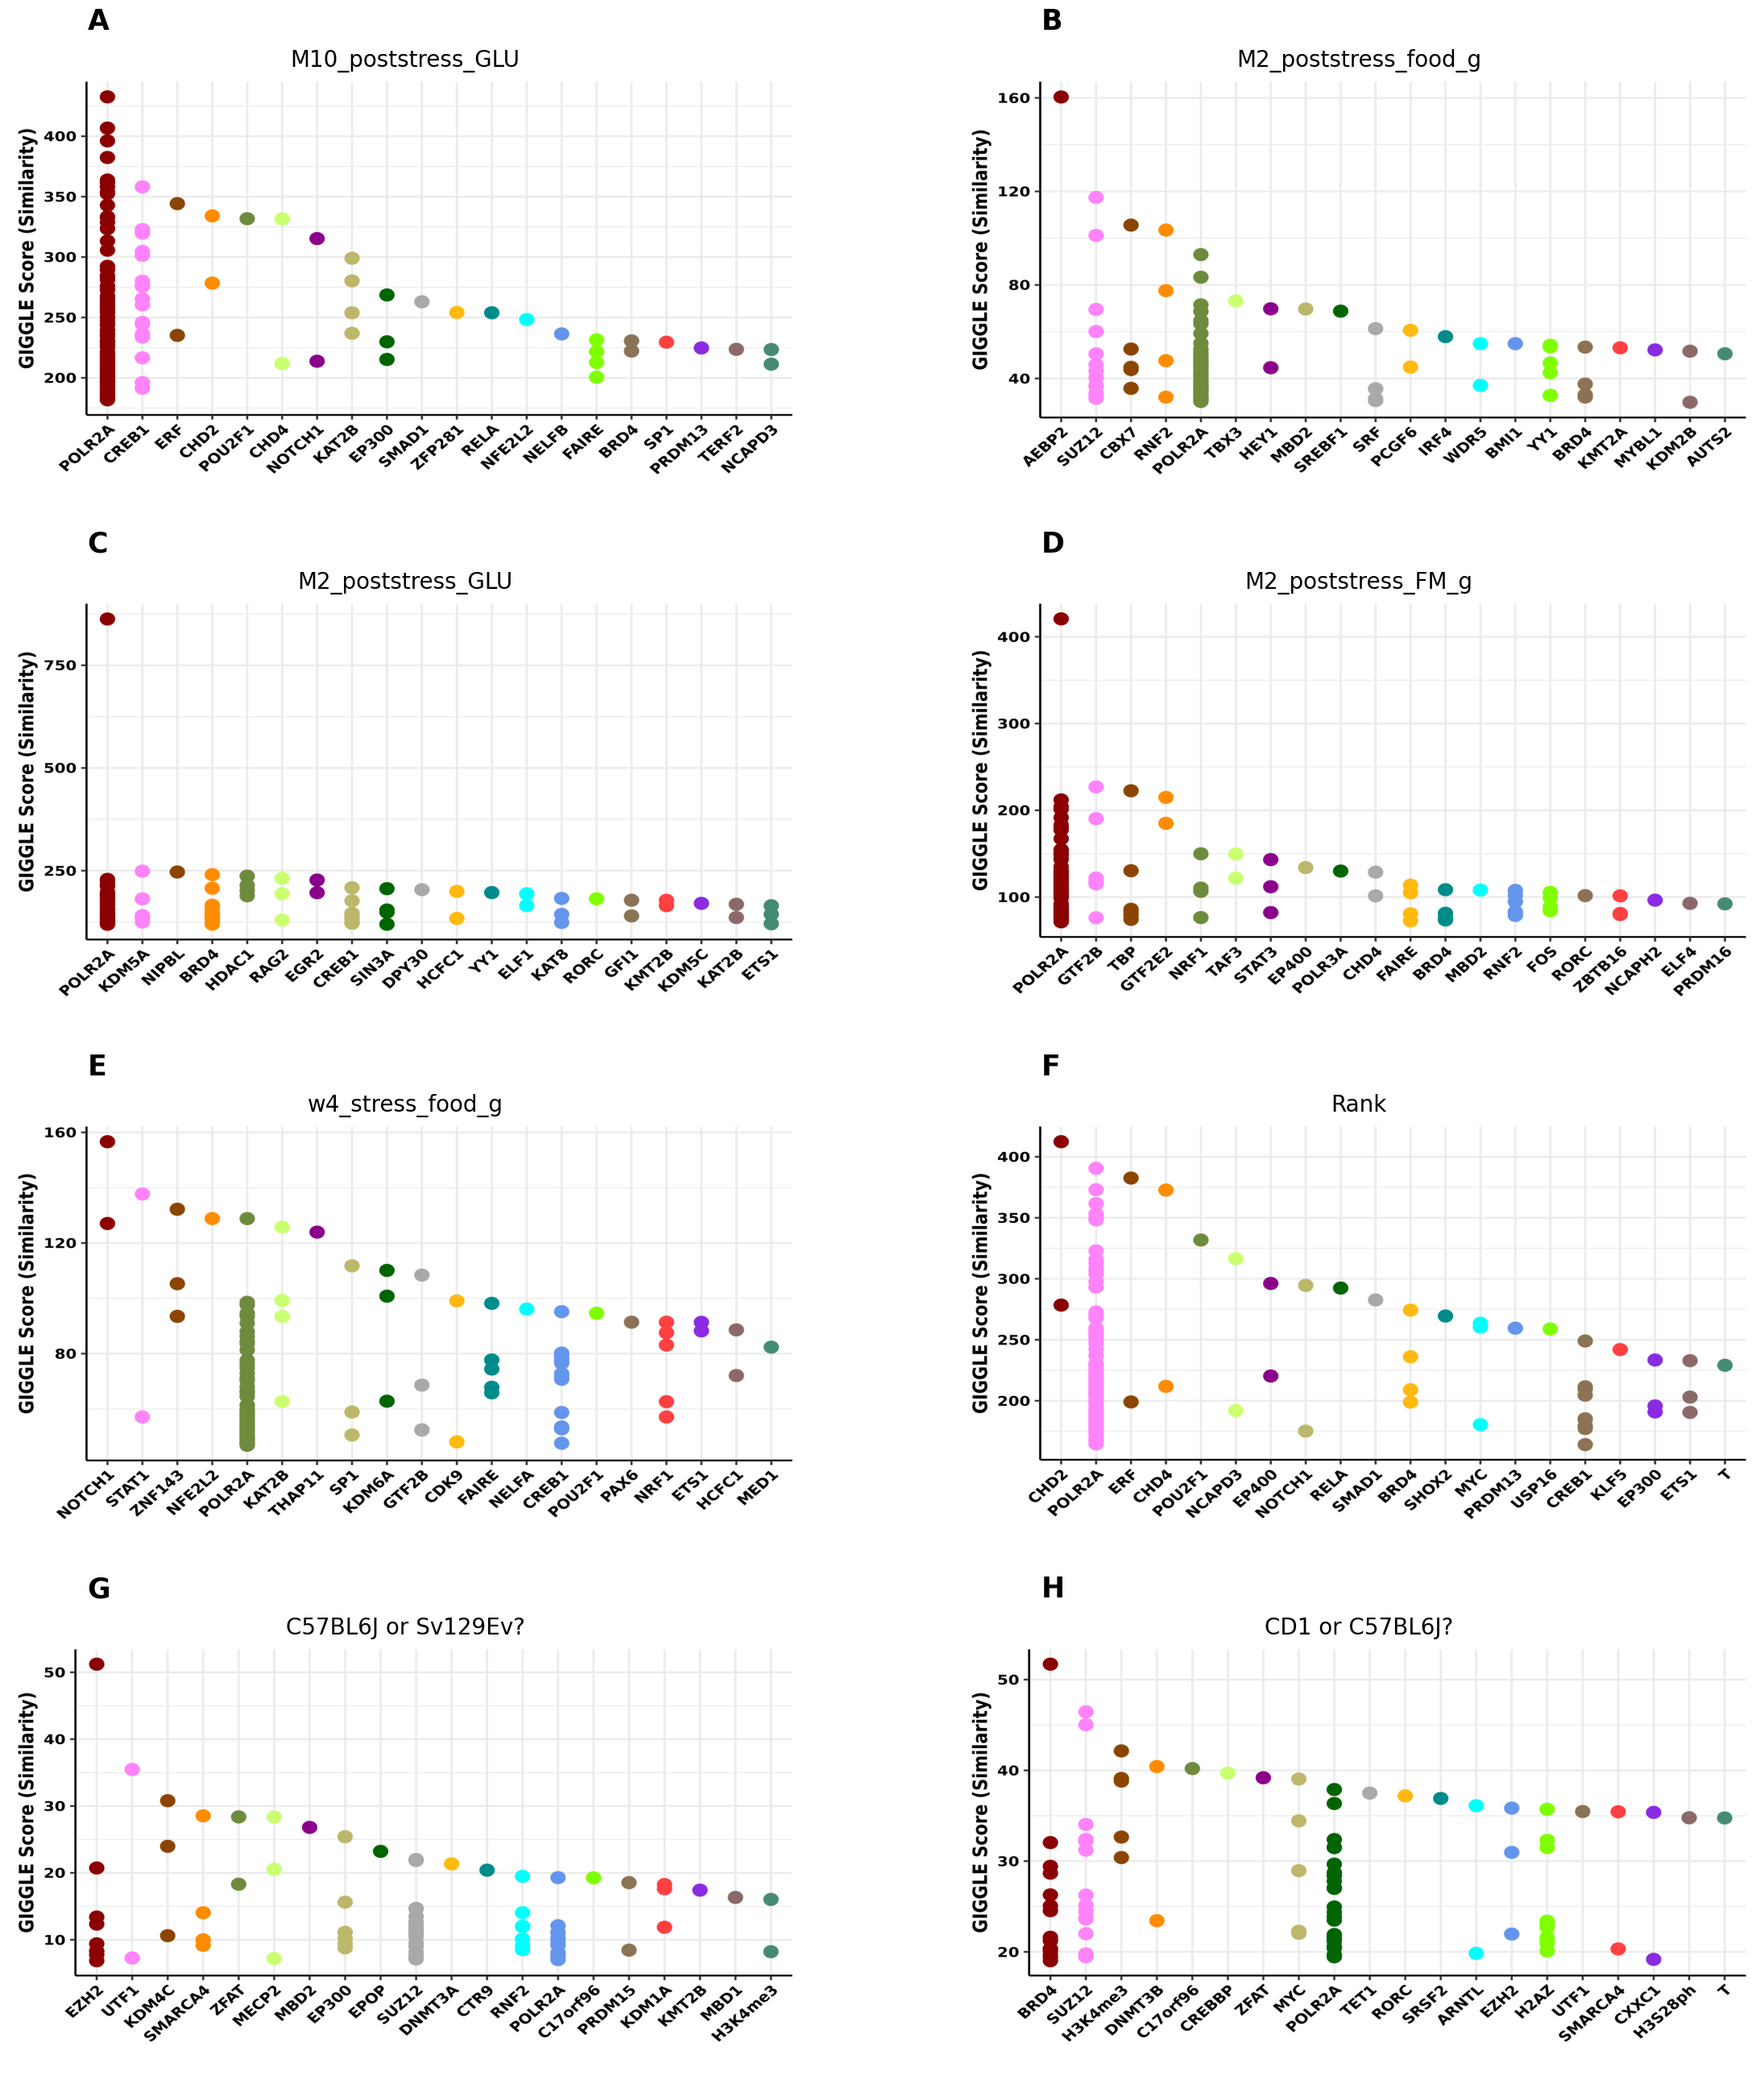

In [11]:
#get cistrome plots using unfiltered probes (so a larger set to select from)

%matplotlib inline

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 6600 

#generate cistrome plots by trait
get_cistrome(trait_vals, fig_w, fig_h)